### Import packages

In [180]:
import pandas as pd
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from xgboost import XGBClassifier
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from xgboost import plot_tree
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, fbeta_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from xgboost import to_graphviz
from sklearn.metrics import make_scorer, f1_score, recall_score, precision_score
from sklearn.feature_selection import RFECV,SequentialFeatureSelector
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold,cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import confusion_matrix, precision_score
from sklearn.metrics import confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import LinearSVC
from sklearn.metrics import roc_curve, roc_auc_score
from imblearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns

# BNPL1 - Full data

### Data preprocessing

1. LOAD DATA

In [181]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_15334/2634253260.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [182]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C']).loc[-data['BNPL1'].isna()].isna().sum()

weight          0
BNPL1           0
EF3_a           0
EF3_b           0
EF3_c           0
EF3_d           0
EF3_e           0
EF3_f           0
EF3_g           0
EF3_h           0
I20             0
ppfs0596    15375
ppeducat        0
ppage           0
ppagecat        0
ppethm          0
ppgender        0
ppinc7          0
ppemploy        0
ppmarit5        0
pphhsize        0
ppkid017        0
ppfs1482     7202
B3              0
A6              0
C4A          6901
EF1             0
L0C         36413
dtype: int64

comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

Drop nas

In [183]:
# drop columns
data_cleaned = data.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])
data_cleaned.loc[-data_cleaned['BNPL1'].isna()].isna().sum()

# independent variables
X = data_cleaned.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned['BNPL1']

# weights
weights = data_cleaned['weight']


Check X columns

In [184]:
pd.DataFrame([(c,X[c].unique()) for c in X.columns], columns=['column', 'values'])

,column,values
0,EF3_a,"[Yes, No]"
1,EF3_b,"[No, Yes]"
2,EF3_c,"[No, Yes]"
3,EF3_d,"[No, Yes]"
4,EF3_e,"[No, Yes]"
5,EF3_f,"[No, Yes]"
6,EF3_g,"[No, Yes]"
7,EF3_h,"[No, Yes]"
8,I20,"[The same as your income, More than your incom..."
9,ppfs0596,"[$50,000 - $99,999, Not sure, Under $50,000, n..."


Data transformation

In [185]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [186]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }

# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3,5],
    'min_child_weight': [5, 10],
    'subsample': [0.8],
    'colsample_bytree': [0.8],
    'gamma': [0.1, 0.5, 1]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])

scoring = {
    'f1_class1': make_scorer(f1_score, pos_label=1),
    'recall_class1': make_scorer(recall_score, pos_label=1),
    'precision_class1': make_scorer(precision_score, pos_label=1)
}

# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="auc",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='roc_auc',   # AUC metric
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)

# Prediction
y_pred = grid_search.predict(X_test)


Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.8s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=100, subsample=0.8; total time=   0.9s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=0.05, max_depth=3, min_child_weight=5, n_estimators=200, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, gamma=0.1, learning_rate=

KeyboardInterrupt: 

Show results

Best Parmaters: {'colsample_bytree': 0.8, 'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 200, 'subsample': 0.8}
AUC: 0.8615881457783854


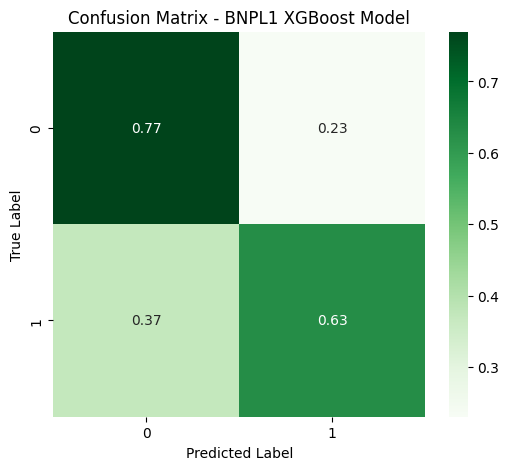

In [ ]:
# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 XGBoost Model")
plt.show()


### Display tree

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


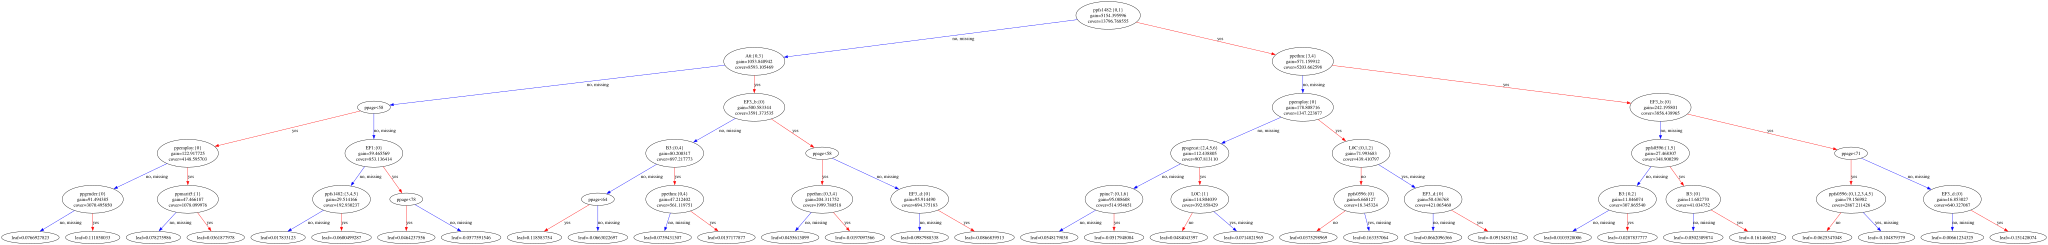

In [ ]:
# best model
best_model = grid_search.best_estimator_

graph = to_graphviz(best_model, num_trees=0)
graph

## BNPL3 - full data

### Data preprocessing

In [ ]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_15334/2634253260.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [ ]:
# check nas
pd.set_option('display.max_rows', None)

data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
               'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C']).loc[-data['BNPL3'].isna()].isna().sum()

weight         0
BNPL3          0
EF3_a          0
EF3_b          0
EF3_c          0
EF3_d          0
EF3_e          0
EF3_f          0
EF3_g          0
EF3_h          0
I20            0
ppfs0596    2178
ppeducat       0
ppage          0
ppagecat       0
ppethm         0
ppgender       0
ppinc7         0
ppemploy       0
ppmarit5       0
pphhsize       0
ppkid017       0
ppfs1482    1180
B3             0
A6             0
C4A          854
EF1            0
L0C         3774
dtype: int64

comment: leaving out columns SL6, I41_c, I41_e, A1_a, A1_b, A1_c, X12_a, X12_b, X12_c, X12_d, X12_e, X12_f, X12_g, EF5C from full data regression. include these columns for 2024 year regression.

Drop nas

In [ ]:
# drop columns
data_cleaned = data.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year',
                       'SL6', 'I41_c', 'I41_e', 'A1_a', 'A1_b', 'A1_c', 'X12_a', 'X12_b', 'X12_c', 'X12_d', 'X12_e', 'X12_f', 'X12_g', 'EF5C'])

In [ ]:
data_cleaned = data_cleaned.dropna()

In [ ]:
# independent variables
X = data_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_cleaned['BNPL3']

# weights
weights = data_cleaned['weight']


Data tranformation

In [ ]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [188]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])


# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='f1',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 96 candidates, totalling 480 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.1, scale_pos_weight=7.57065094125652, subsample=0.8; total time=   1.4s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.1, scale_pos_weight=7.57065094125652, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.1, scale_pos_weight=7.57065094125652, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=200, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   1.5s
[CV] END colsample_bytree=0.8, learnin

Show results

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 500, 'reg_alpha': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
AUC: 0.8541848375482003


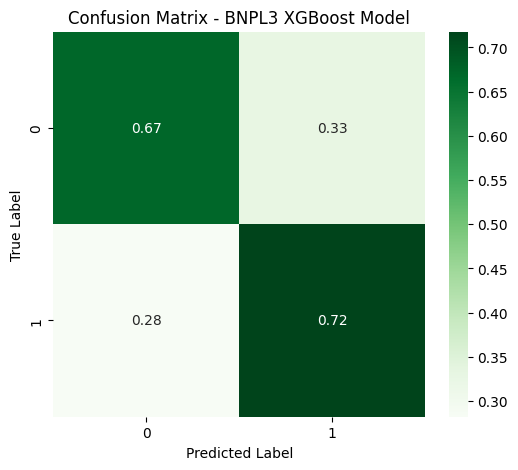

In [191]:
# Get probabilities for Class 1
y_probs = grid_search.predict_proba(X_test)[:, 1]

# Lower threshold to improve Recall for Class 1
threshold = 0.35
y_pred_adjusted = (y_probs >= threshold).astype(int)

# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred_adjusted, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 XGBoost Model")
plt.show()


### Display tree

/Users/kirawei/.pyenv/versions/3.11.5/lib/python3.11/site-packages/xgboost/plotting.py:267: FutureWarning: The `num_trees` parameter is deprecated, use `tree_idx` insetad. 
  warnings.warn(


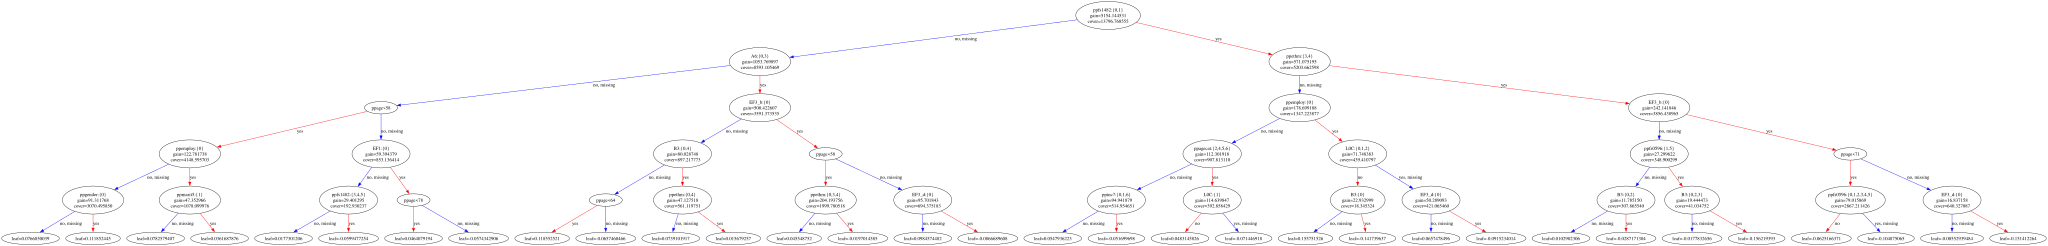

In [192]:
# best model
best_model_BNPL3 = grid_search.best_estimator_

graph_BNPL3 = to_graphviz(best_model_BNPL3, num_trees=0)
graph_BNPL3

## BNPL1 - 2024 data

### Data pre-processing

In [207]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_15334/2448053278.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [209]:
# check nas
pd.set_option('display.max_rows', None)

data_2024.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year','SL6','ppfs0596','I41_e','I41_c'
            ]).loc[-data_2024['BNPL1'].isna()].isna().sum()

weight         0
BNPL1          0
EF3_a          0
EF3_b          0
EF3_c          0
EF3_d          0
EF3_e          0
EF3_f          0
EF3_g          0
EF3_h          0
I20            0
ppeducat       0
ppage          0
ppagecat       0
ppethm         0
ppgender       0
ppinc7         0
ppemploy       0
ppmarit5       0
pphhsize       0
ppkid017       0
ppfs1482    2550
B3             0
A6             0
C4A         1946
EF1            0
L0C         9511
A1_a        8184
A1_b        8184
A1_c        8184
X12_a       6170
X12_b       6170
X12_c       6170
X12_d       6170
X12_e       6170
X12_f       6170
X12_g       6170
EF5C           0
dtype: int64

In [ ]:
# drop columns
data_cleaned_2024 = data_2024.drop(columns=['BNPL3', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year','SL6','ppfs0596','I41_e','I41_c'
            ])

In [211]:
# drop columns
data_cleaned_2024 = data_cleaned_2024.dropna()

In [213]:
# independent variables
X = data_cleaned_2024.drop(columns=['BNPL1','weight'])
# target variable
y = data_cleaned_2024['BNPL1']

# weights
weights = data_cleaned_2024['weight']


Data transformation

In [216]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [219]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])


# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='f1',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.1s[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.1s

[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.1s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_child_weight': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
AUC: 0.9056304216102454


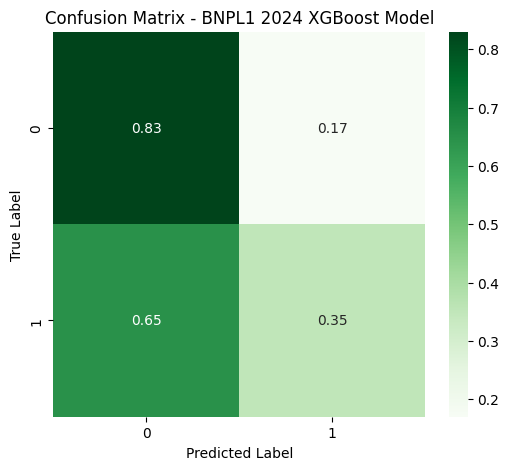

In [220]:
# Get probabilities for Class 1
y_probs = grid_search.predict_proba(X_test)[:, 1]

# Lower threshold to improve Recall for Class 1
threshold = 0.35
y_pred_adjusted = (y_probs >= threshold).astype(int)

# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred_adjusted, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL1 2024 XGBoost Model")
plt.show()


## BNPL3 - 2024 data

### Data pre-processing

In [264]:
# load data
data = pd.read_csv('data/data_merged.csv', index_col=False)
data = data.iloc[:,1:]
data_2024 = data.loc[data['year']==2024]

/var/folders/cr/df6gvtx90rz5bg2m0clb1gym0000gn/T/ipykernel_15334/2448053278.py:2: DtypeWarning: Columns (0: X12_a, 1: X12_b, 2: X12_c, 3: X12_d, 4: X12_e, 5: X12_f, 6: X12_g, 7: EF5C) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('data/data_merged.csv', index_col=False)


In [265]:
# check nas
pd.set_option('display.max_rows', None)

data_2024_cleaned = data_2024.drop(columns=['BNPL1', 'BNPL4_a', 'BNPL4_b', 'BNPL4_c', 'BNPL4_d', 'BNPL4_e', 'BNPL4_f', 'year','SL6','ppfs0596','I41_e','I41_c','SL6','ppfs0596'
            ])

In [266]:
data_2024_cleaned= data_2024_cleaned.dropna()

In [267]:
# independent variables
X = data_2024_cleaned.drop(columns=['BNPL3','weight'])
# target variable
y = data_2024_cleaned['BNPL3']

# weights
weights = data_2024_cleaned['weight']


Data transformation

In [268]:
# to ordinal
cols1 = ['pphhsize','ppage','ppkid017']
for c in cols1:
  X[c] = X[c].astype(float)

# to categorical
cols2 = [c for c in X.columns if c not in cols1]
for c in cols2:
  X[c] = X[c].astype("category")

y = y.map({'No': 0, 'Yes': 1})

### XGBoost

Modeling

In [269]:
xgb_results = []
# ---------------------------
# 1. Prepare data
# ---------------------------
X_aug = X.copy()
X_aug["weight"] = weights

# ---------------------------
# 2. Train-test split
# ---------------------------
X_train_aug, X_test_aug, y_train, y_test = train_test_split(
    X_aug, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------------
# 3. Cross-validation
# ---------------------------
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# param_grid = {
#     'n_estimators': [500, 200],
#     'learning_rate': [0.05, 0.1],
#     'max_depth': [3, 5, 7],
#     'min_child_weight': [1, 3],
#     'subsample': [0.8],
#     'colsample_bytree': [0.8],
#     'gamma': [0, 0.1, 0.3]
# }
counts = y_train.value_counts()
ratio = counts[0] / counts[1]
# ---------------------------
# 4. Build hyperparameters grid
# ---------------------------
param_grid = {
    'n_estimators': [100, 200, 500],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_child_weight': [1, 5],
    'scale_pos_weight': [1, ratio, ratio *1.5],
    'reg_alpha': [0.1, 1],          # L1 Regularization
    'subsample': [0.8],
    'colsample_bytree': [0.8]
}

# Resample ONLY training fold
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res = ros.fit_resample(X_train_aug, y_train)

# Extract weights
w_train_res = X_train_res["weight"].values
X_train_res = X_train_res.drop(columns=["weight"])

w_test = X_test_aug["weight"].values
X_test = X_test_aug.drop(columns=["weight"])


# Build model
xgb = XGBClassifier(
objective='binary:logistic',
tree_method="hist",
enable_categorical=True,
eval_metric="logloss",
random_state=42
)

grid_search = GridSearchCV(
estimator=xgb,
param_grid=param_grid,
scoring='f1',
cv=5,                # 5-fold cross-validation
verbose=2,
n_jobs=-1
)

# fit model
grid_search.fit(X_train_res, y_train_res, sample_weight=w_train_res)


Fitting 5 folds for each of 144 candidates, totalling 720 fits
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=2.1904761904761907, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, learning_rate=0.05, max_depth=3, min_child_weight=1, n_estimators=100, reg_alpha=0.1, scale_pos_weight=1, subsample=0.8; total time=   0.0s
[CV] END colsample_bytree=0.8, 

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8], 'learning_rate': [0.05, 0.1], 'max_depth': [3, 5], 'min_child_weight': [1, 5], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate

Evaluation results

Best Parmaters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.1, 'scale_pos_weight': 1, 'subsample': 0.8}
AUC: 0.8704827457243246


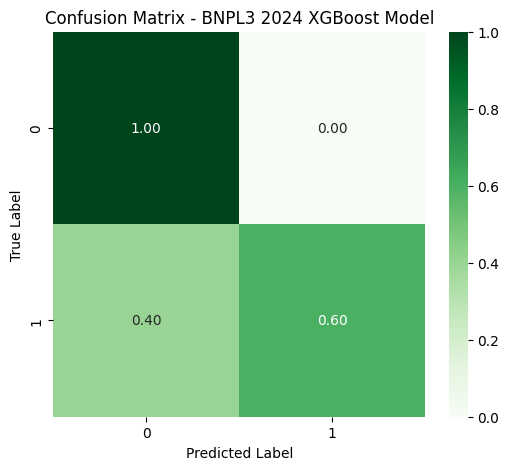

In [270]:
# Get probabilities for Class 1
y_probs = grid_search.predict_proba(X_test)[:, 1]

# Lower threshold to improve Recall for Class 1
threshold = 0.35
y_pred_adjusted = (y_probs >= threshold).astype(int)

# save scores
auc_score = grid_search.best_score_
best_parameters = grid_search.best_params_
cm = confusion_matrix(y_test, y_pred_adjusted, normalize='true')

# auc
print('Best Parmaters:', best_parameters)
print('AUC:', auc_score)
# Confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt=".2f",
    cmap="Greens",
    xticklabels=np.unique(y_train),
    yticklabels=np.unique(y_train)
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BNPL3 2024 XGBoost Model")
plt.show()
